In [1]:
import numpy as np
import torchvision as thv

from torch import torch
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler, SequentialSampler

from utils import Utils
from consts import Consts
from neural_net_training import NeuralNetTraining

In [2]:
data_train = thv.datasets.MNIST(
    root="./data"
    , train=True
    , download=True
    , transform=thv.transforms.ToTensor()
)

I_train = np.random.randint(
    low=0
    , high=data_train.data.shape[0]
    , size=int(data_train.data.shape[0] * Consts.DATASET_SAMPLING_RATIO)
)

loader_train = DataLoader(
    dataset=data_train
    , batch_size=Consts.MINI_BATCH_SIZE
    , sampler=SubsetRandomSampler(I_train)
)

print(I_train.shape)
print(len(loader_train.sampler))

100%|██████████| 9912422/9912422 [00:00<00:00, 21855071.55it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 8801547.18it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw




100%|██████████| 1648877/1648877 [00:00<00:00, 16712358.29it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 2520578.03it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

(60000,)
60000


In [3]:
data_val = thv.datasets.MNIST(
    root="./data"
    , train=False
    , download=True
    , transform=thv.transforms.ToTensor()
)

I_val = np.arange(0, int(data_val.data.shape[0] * Consts.DATASET_SAMPLING_RATIO))

loader_val = DataLoader(
    dataset=data_val
    , batch_size=Consts.MINI_BATCH_SIZE
    , sampler=SequentialSampler(I_val)
)

print(I_val.shape)
print(len(loader_val.sampler))

(10000,)
10000


In [4]:
# P2.1.
training1 = NeuralNetTraining(
    loader_val=loader_val
    , loader_train=loader_train
    , device_name=Utils.get_device_name()
)

training1_idps = training1.train_and_validate()

100%|██████████| 50/50 [03:59<00:00,  4.80s/it]


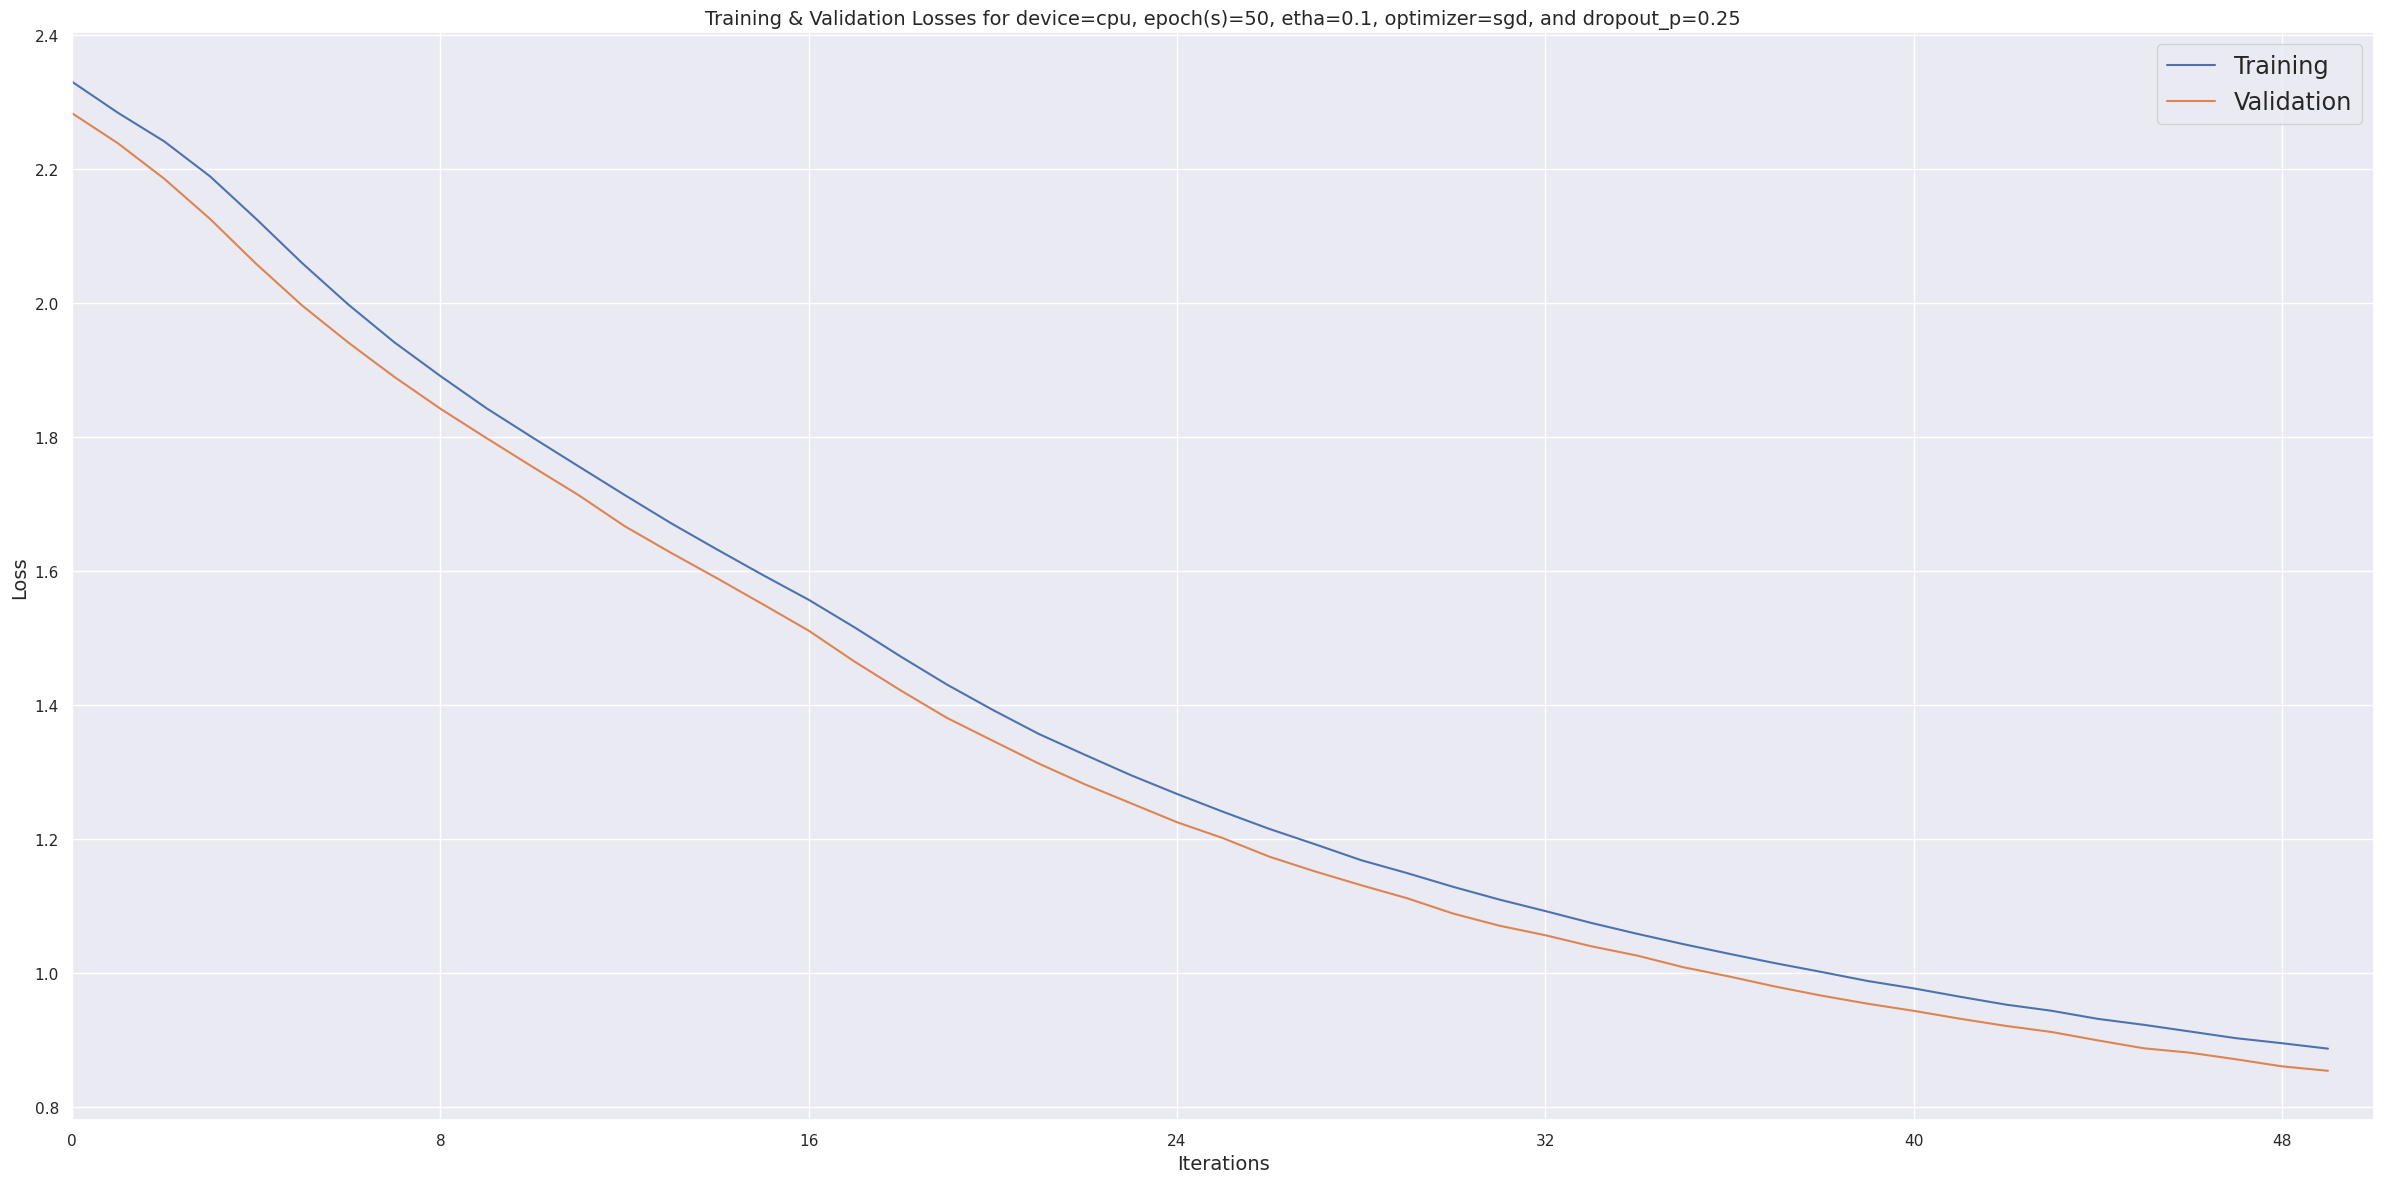

In [5]:
# P2.1.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[idp.iter_idx for idp in training1_idps]
    , y1=[idp.training_loss for idp in training1_idps]
    , y2=[idp.validation_loss for idp in training1_idps]
    , title="Training & Validation Losses for {training}".format(training=training1)
)

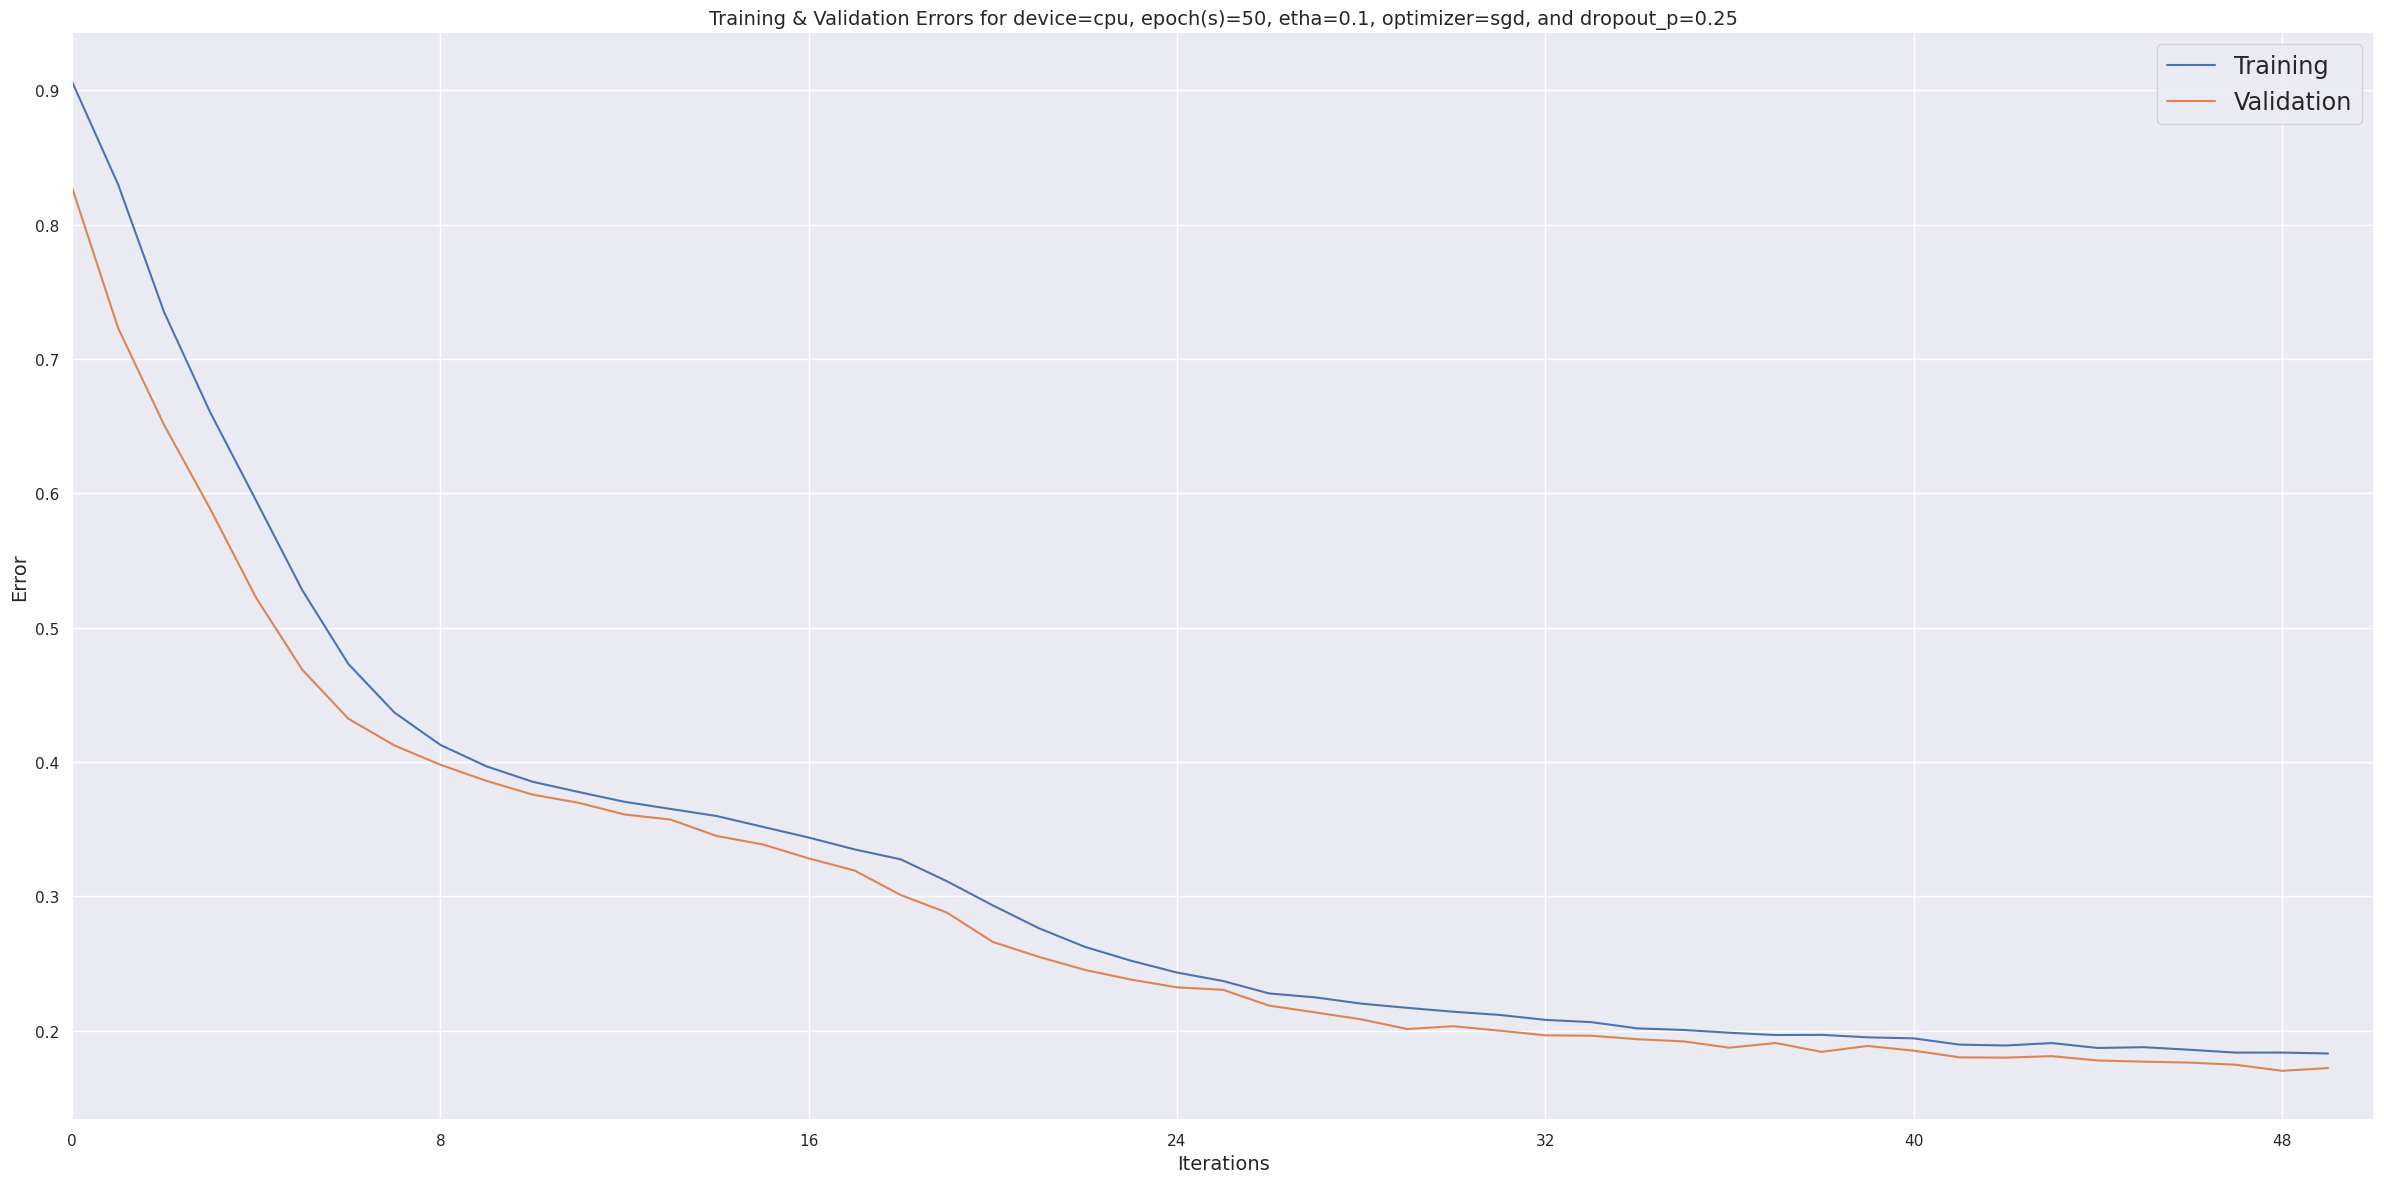

In [6]:
# P2.1.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Error"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[idp.iter_idx for idp in training1_idps]
    , y1=[idp.training_error for idp in training1_idps]
    , y2=[idp.validation_error for idp in training1_idps]
    , title="Training & Validation Errors for {training}".format(training=training1)
)

In [7]:
# P2.1.
training2 = NeuralNetTraining(
    etha=0.01
    , dropout_p=0.25
    , optimizer_alg="sgd"
    , loader_val=loader_val
    , loader_train=loader_train
    , device_name=Utils.get_device_name()
)

training2_idps = training2.train_and_validate()

100%|██████████| 50/50 [03:59<00:00,  4.78s/it]


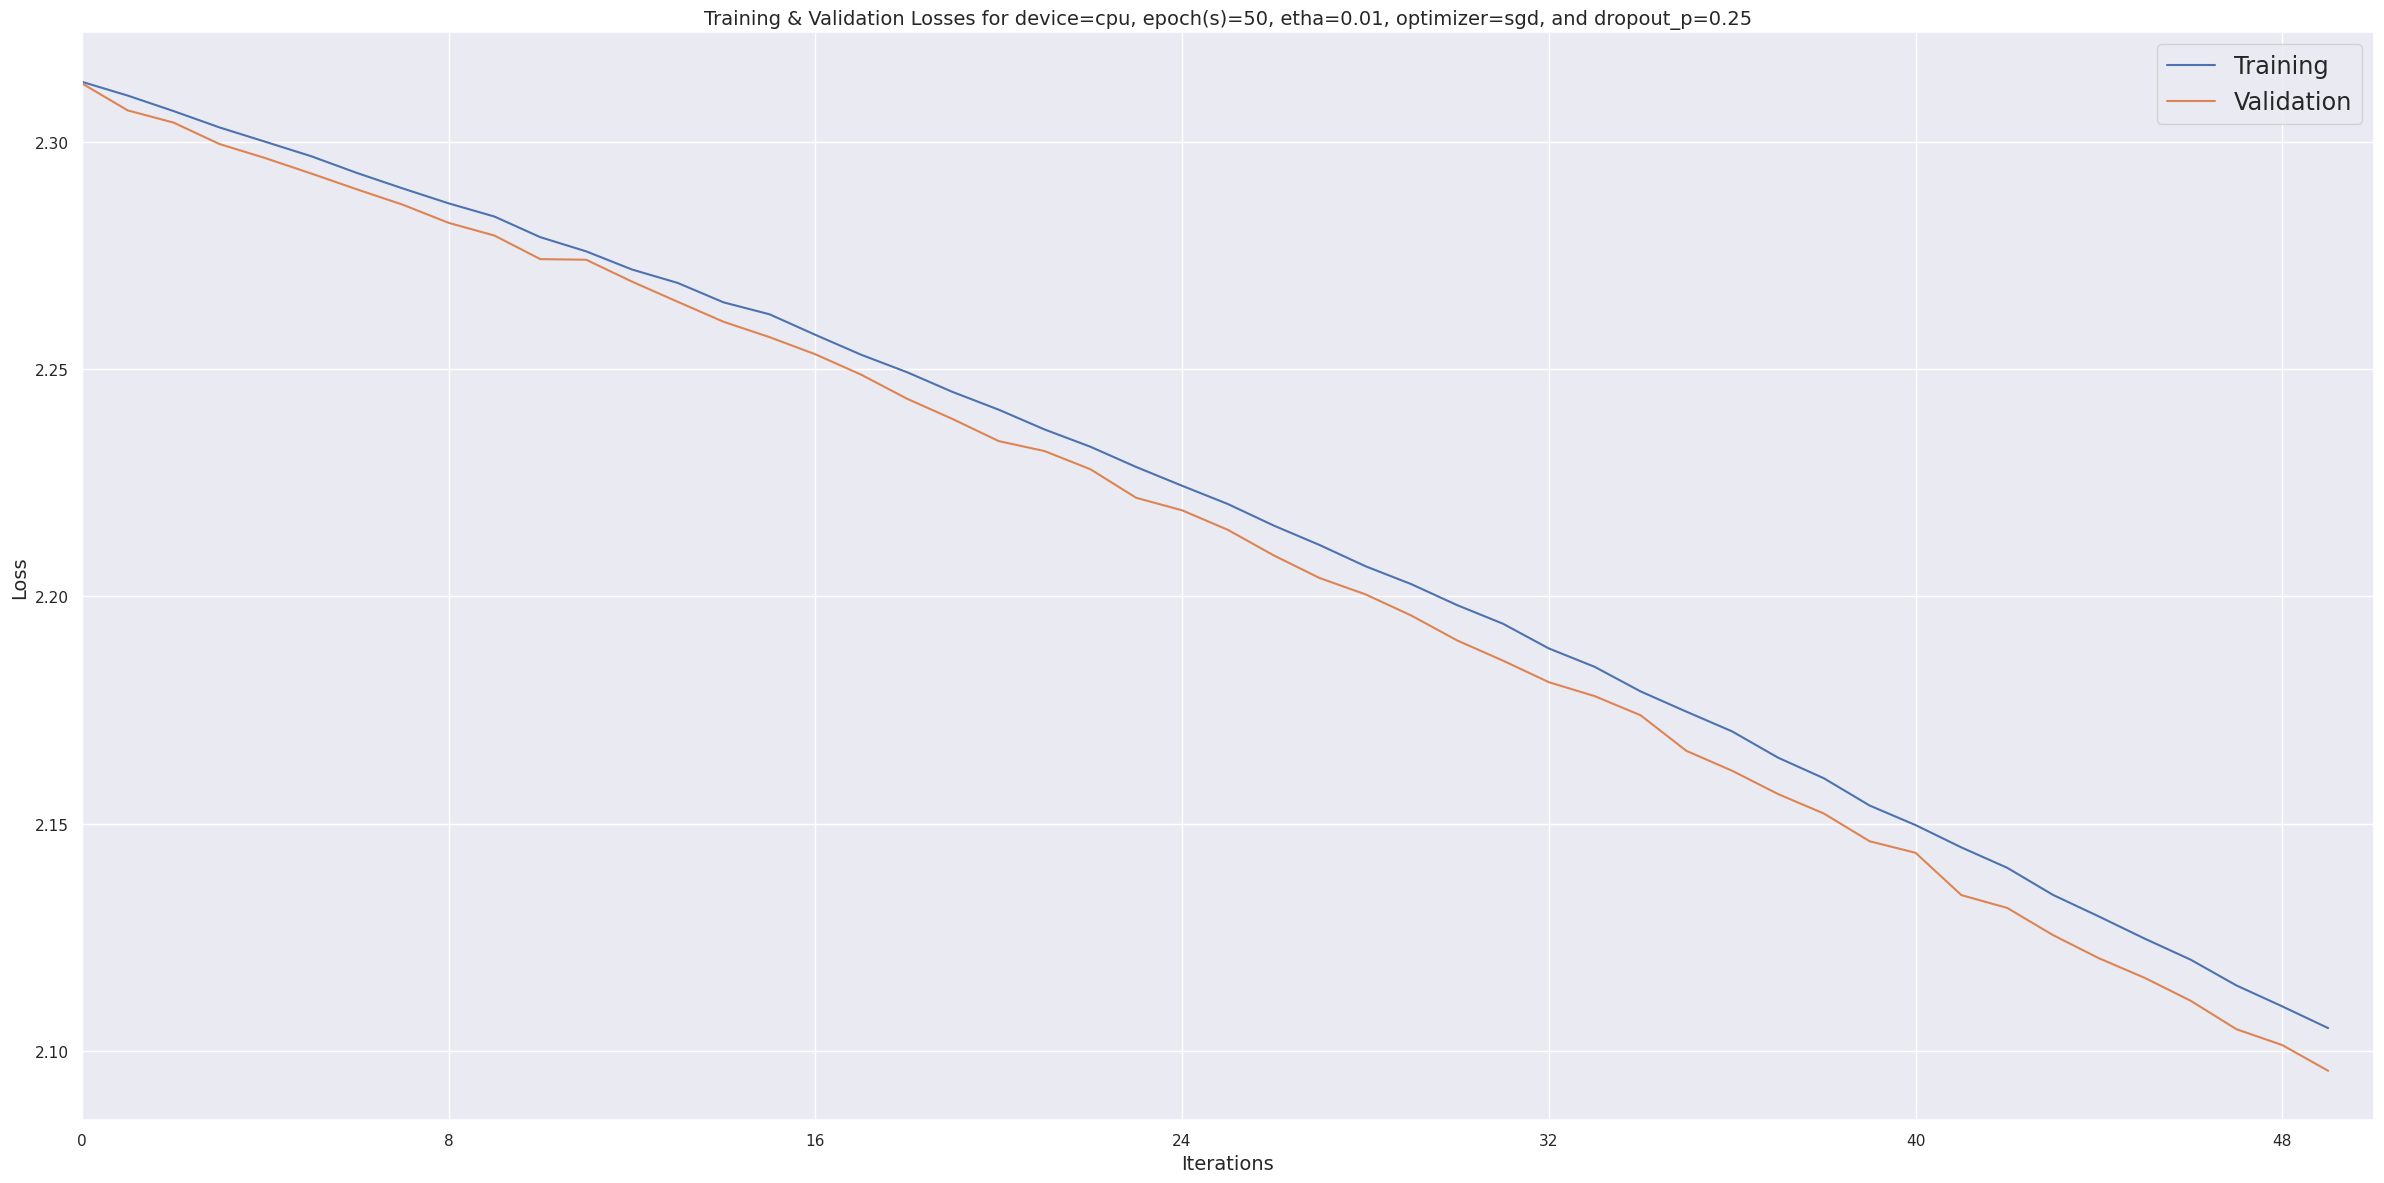

In [8]:
# P2.1.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training2_idps]
    , y1=[tld.training_loss for tld in training2_idps]
    , y2=[tld.validation_loss for tld in training2_idps]
    , title="Training & Validation Losses for {training}".format(training=training2)
)

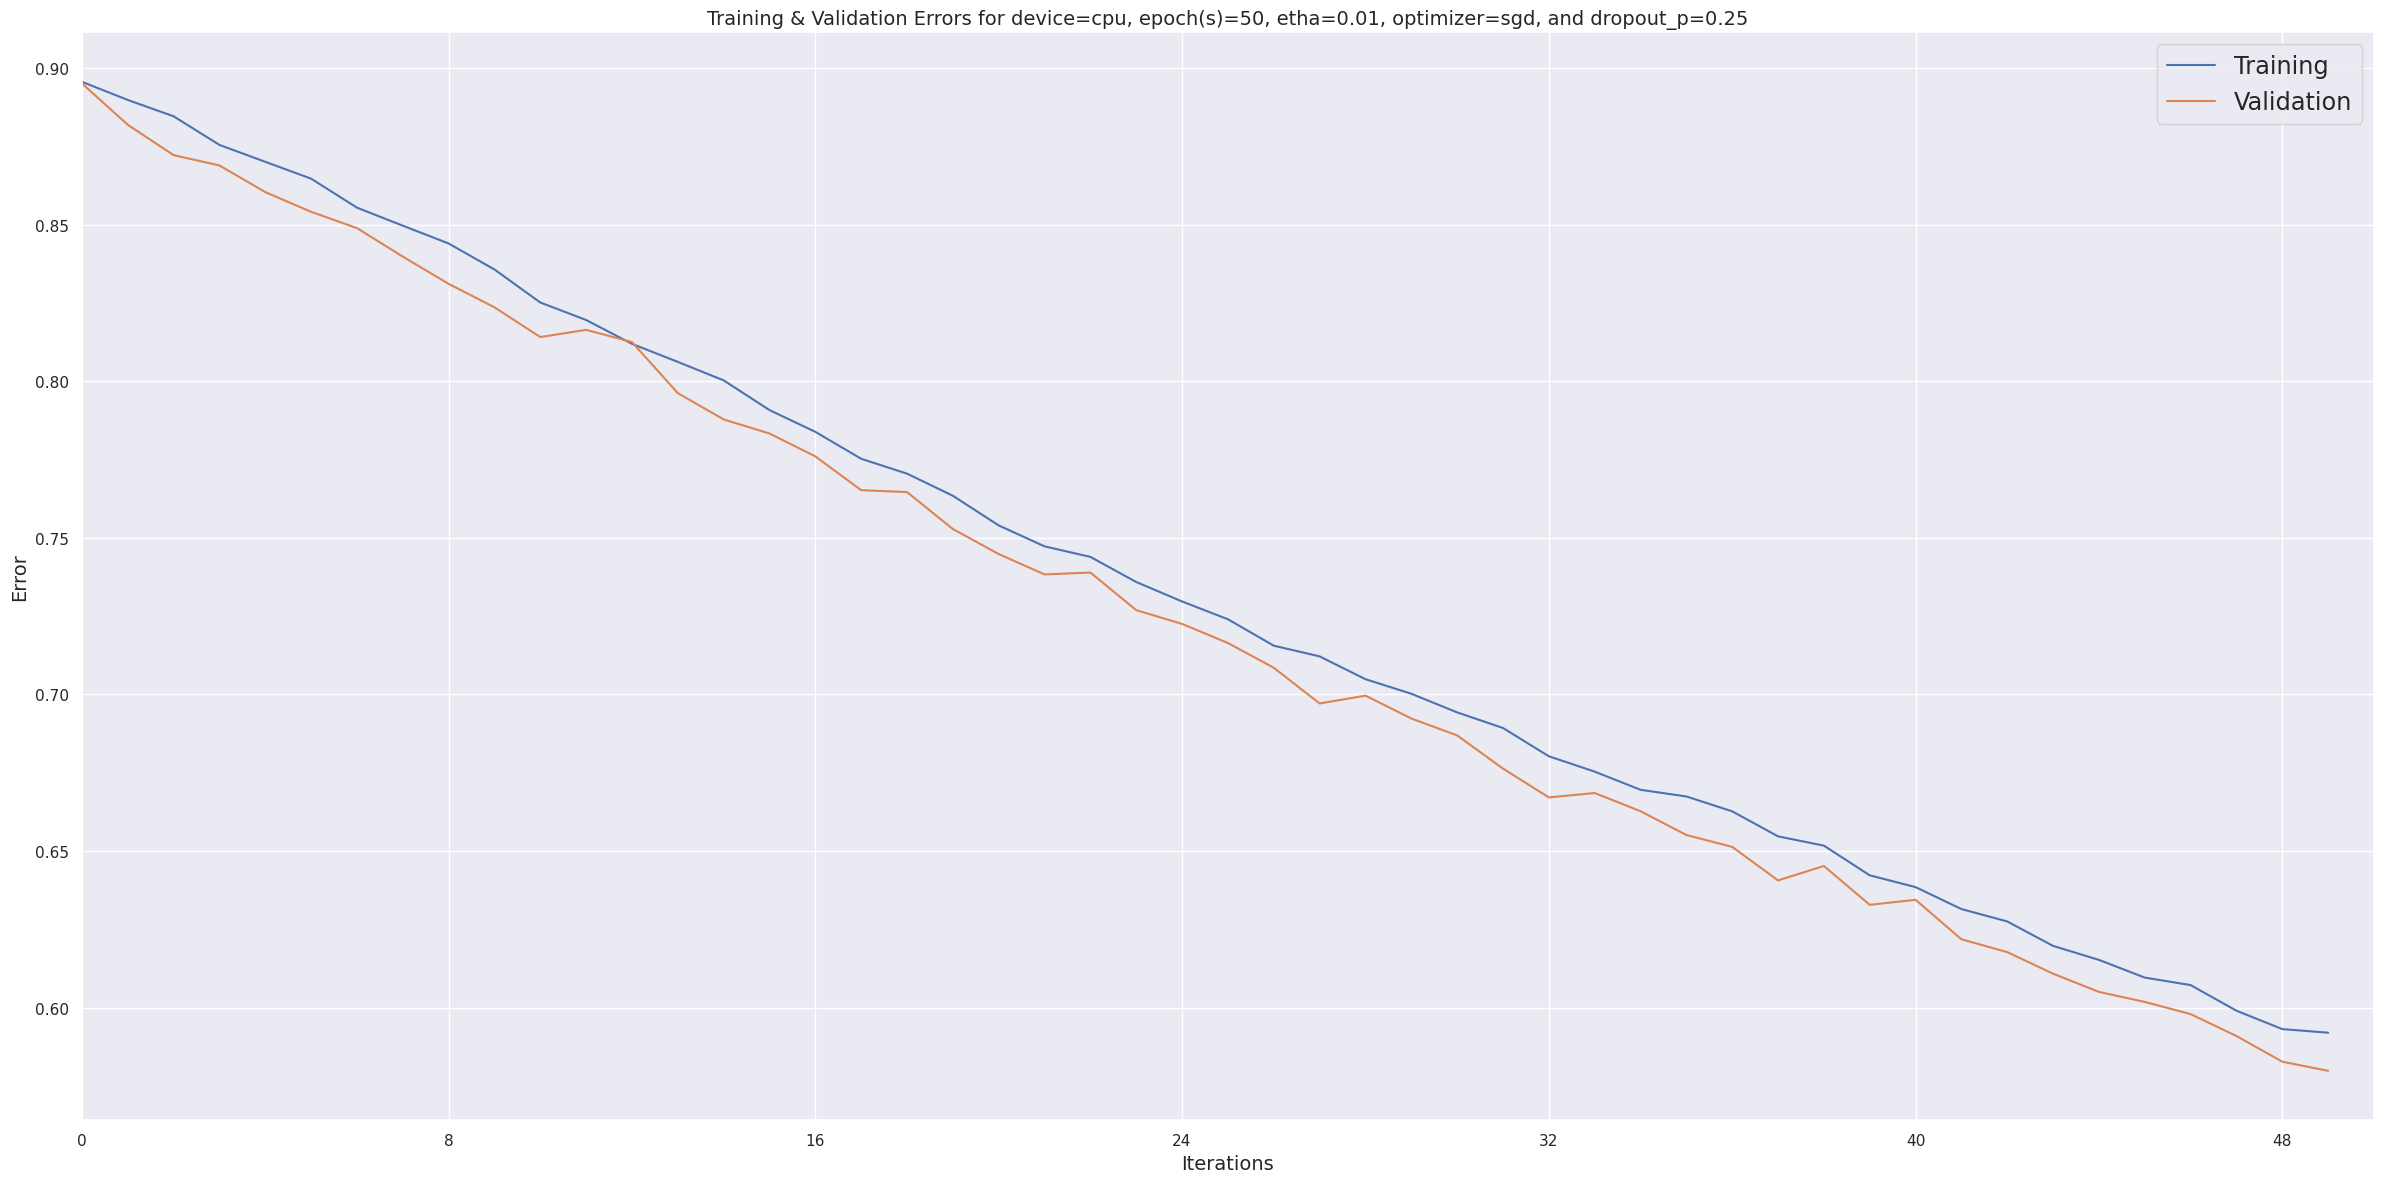

In [9]:
# P2.1.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Error"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training2_idps]
    , y1=[tld.training_error for tld in training2_idps]
    , y2=[tld.validation_error for tld in training2_idps]
    , title="Training & Validation Errors for {training}".format(training=training2)
)

In [10]:
# P2.2.
training3 = NeuralNetTraining(
    etha=0.1
    , dropout_p=0.5
    , optimizer_alg="adam"
    , loader_val=loader_val
    , loader_train=loader_train
    , device_name=Utils.get_device_name()
)

training3_idps = training3.train_and_validate()

100%|██████████| 50/50 [04:16<00:00,  5.12s/it]


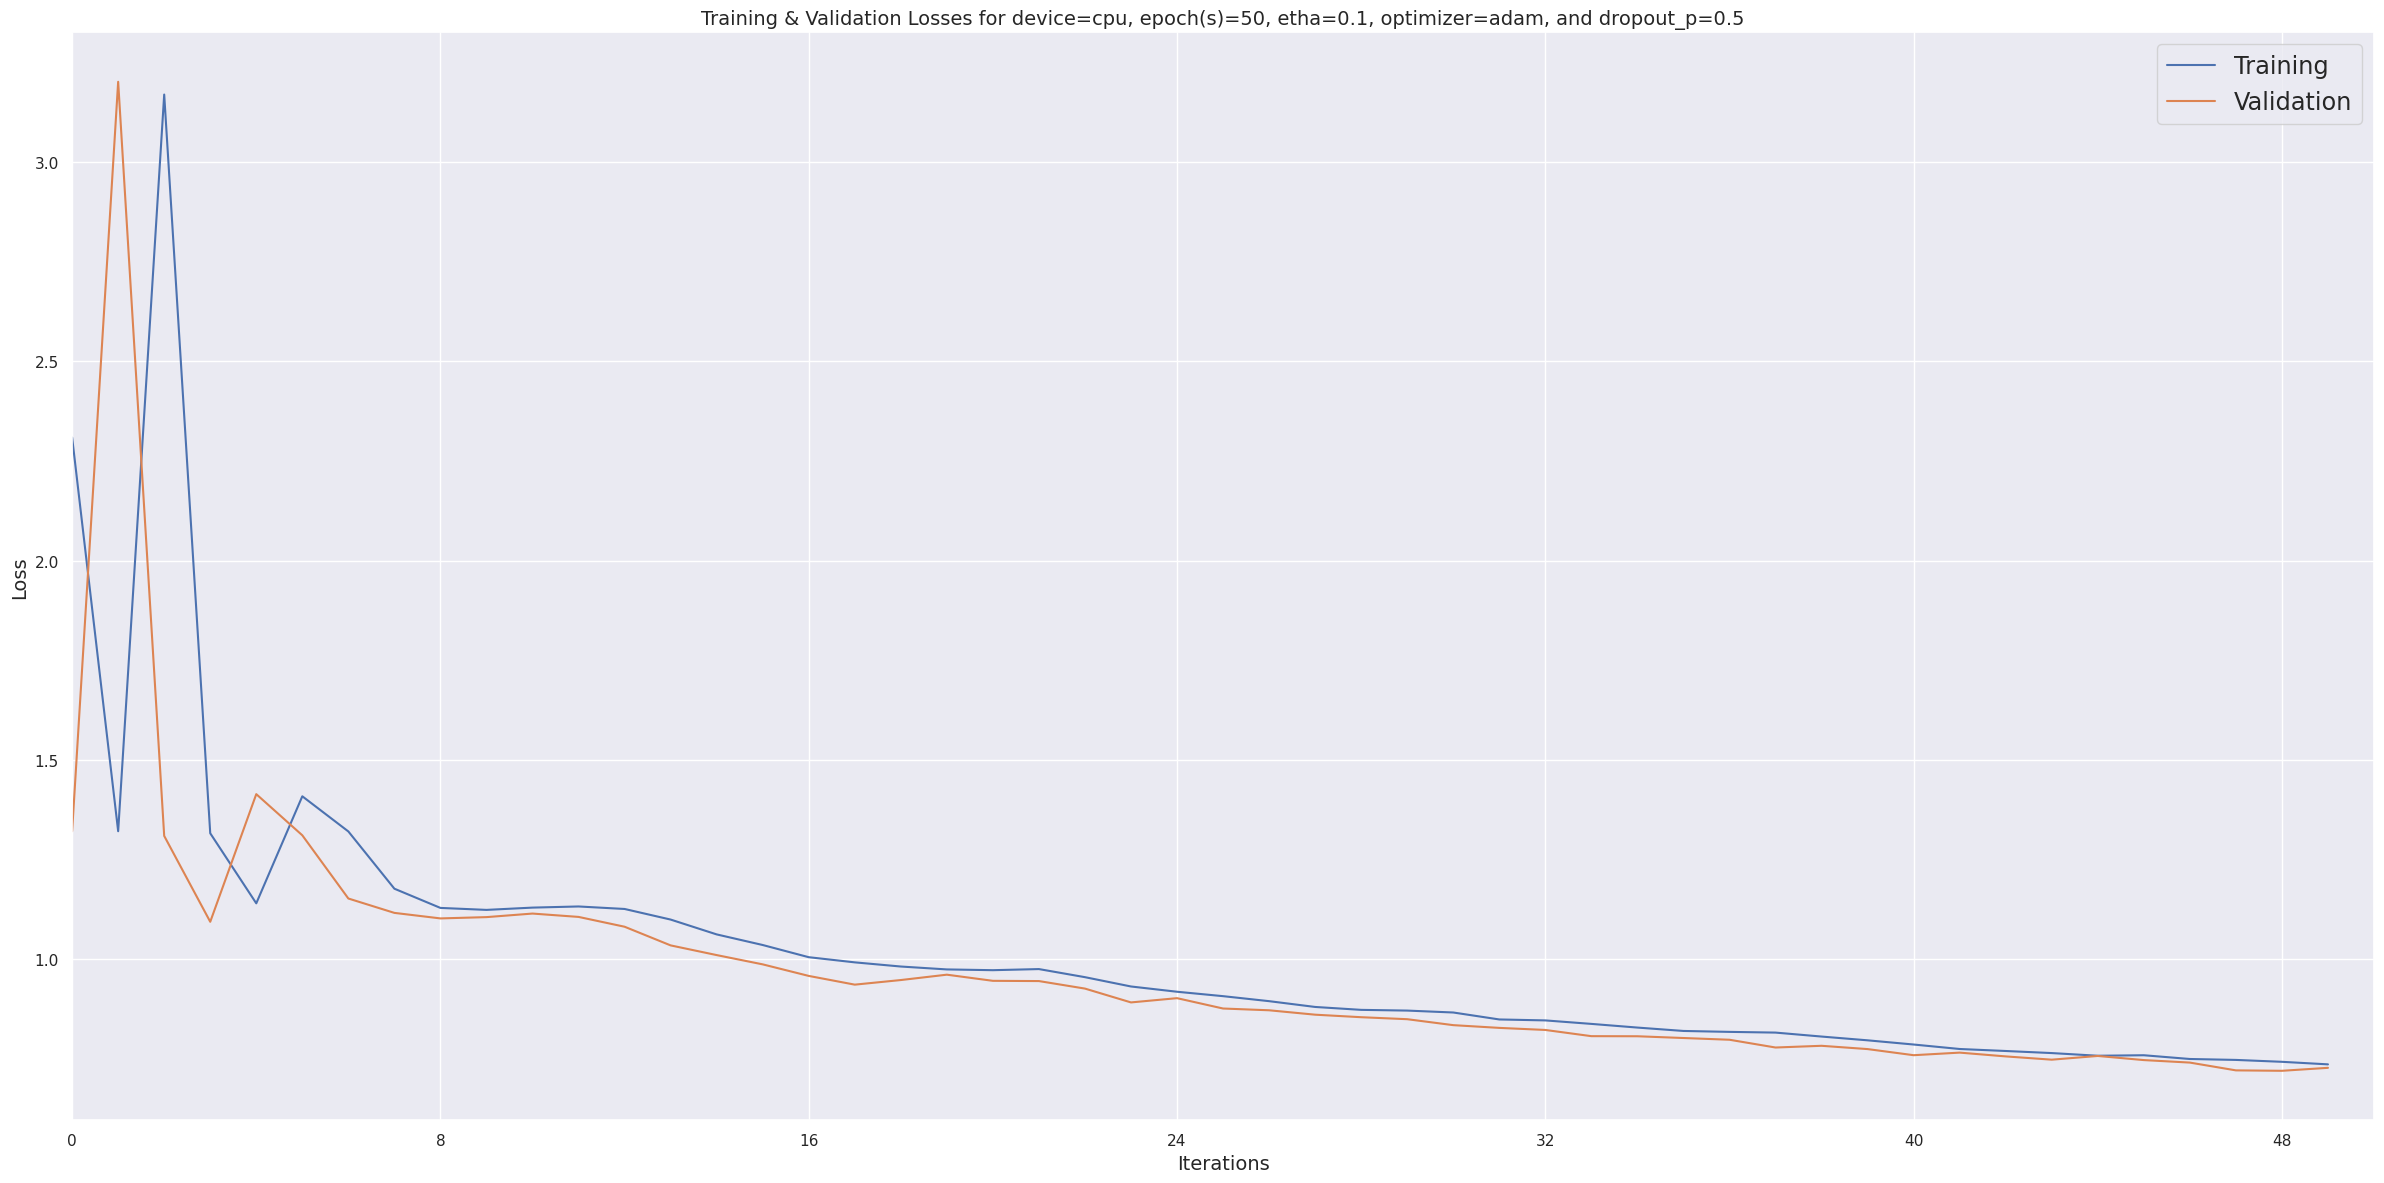

In [11]:
# P2.2.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training3_idps]
    , y1=[tld.training_loss for tld in training3_idps]
    , y2=[tld.validation_loss for tld in training3_idps]
    , title="Training & Validation Losses for {training}".format(training=training3)
)

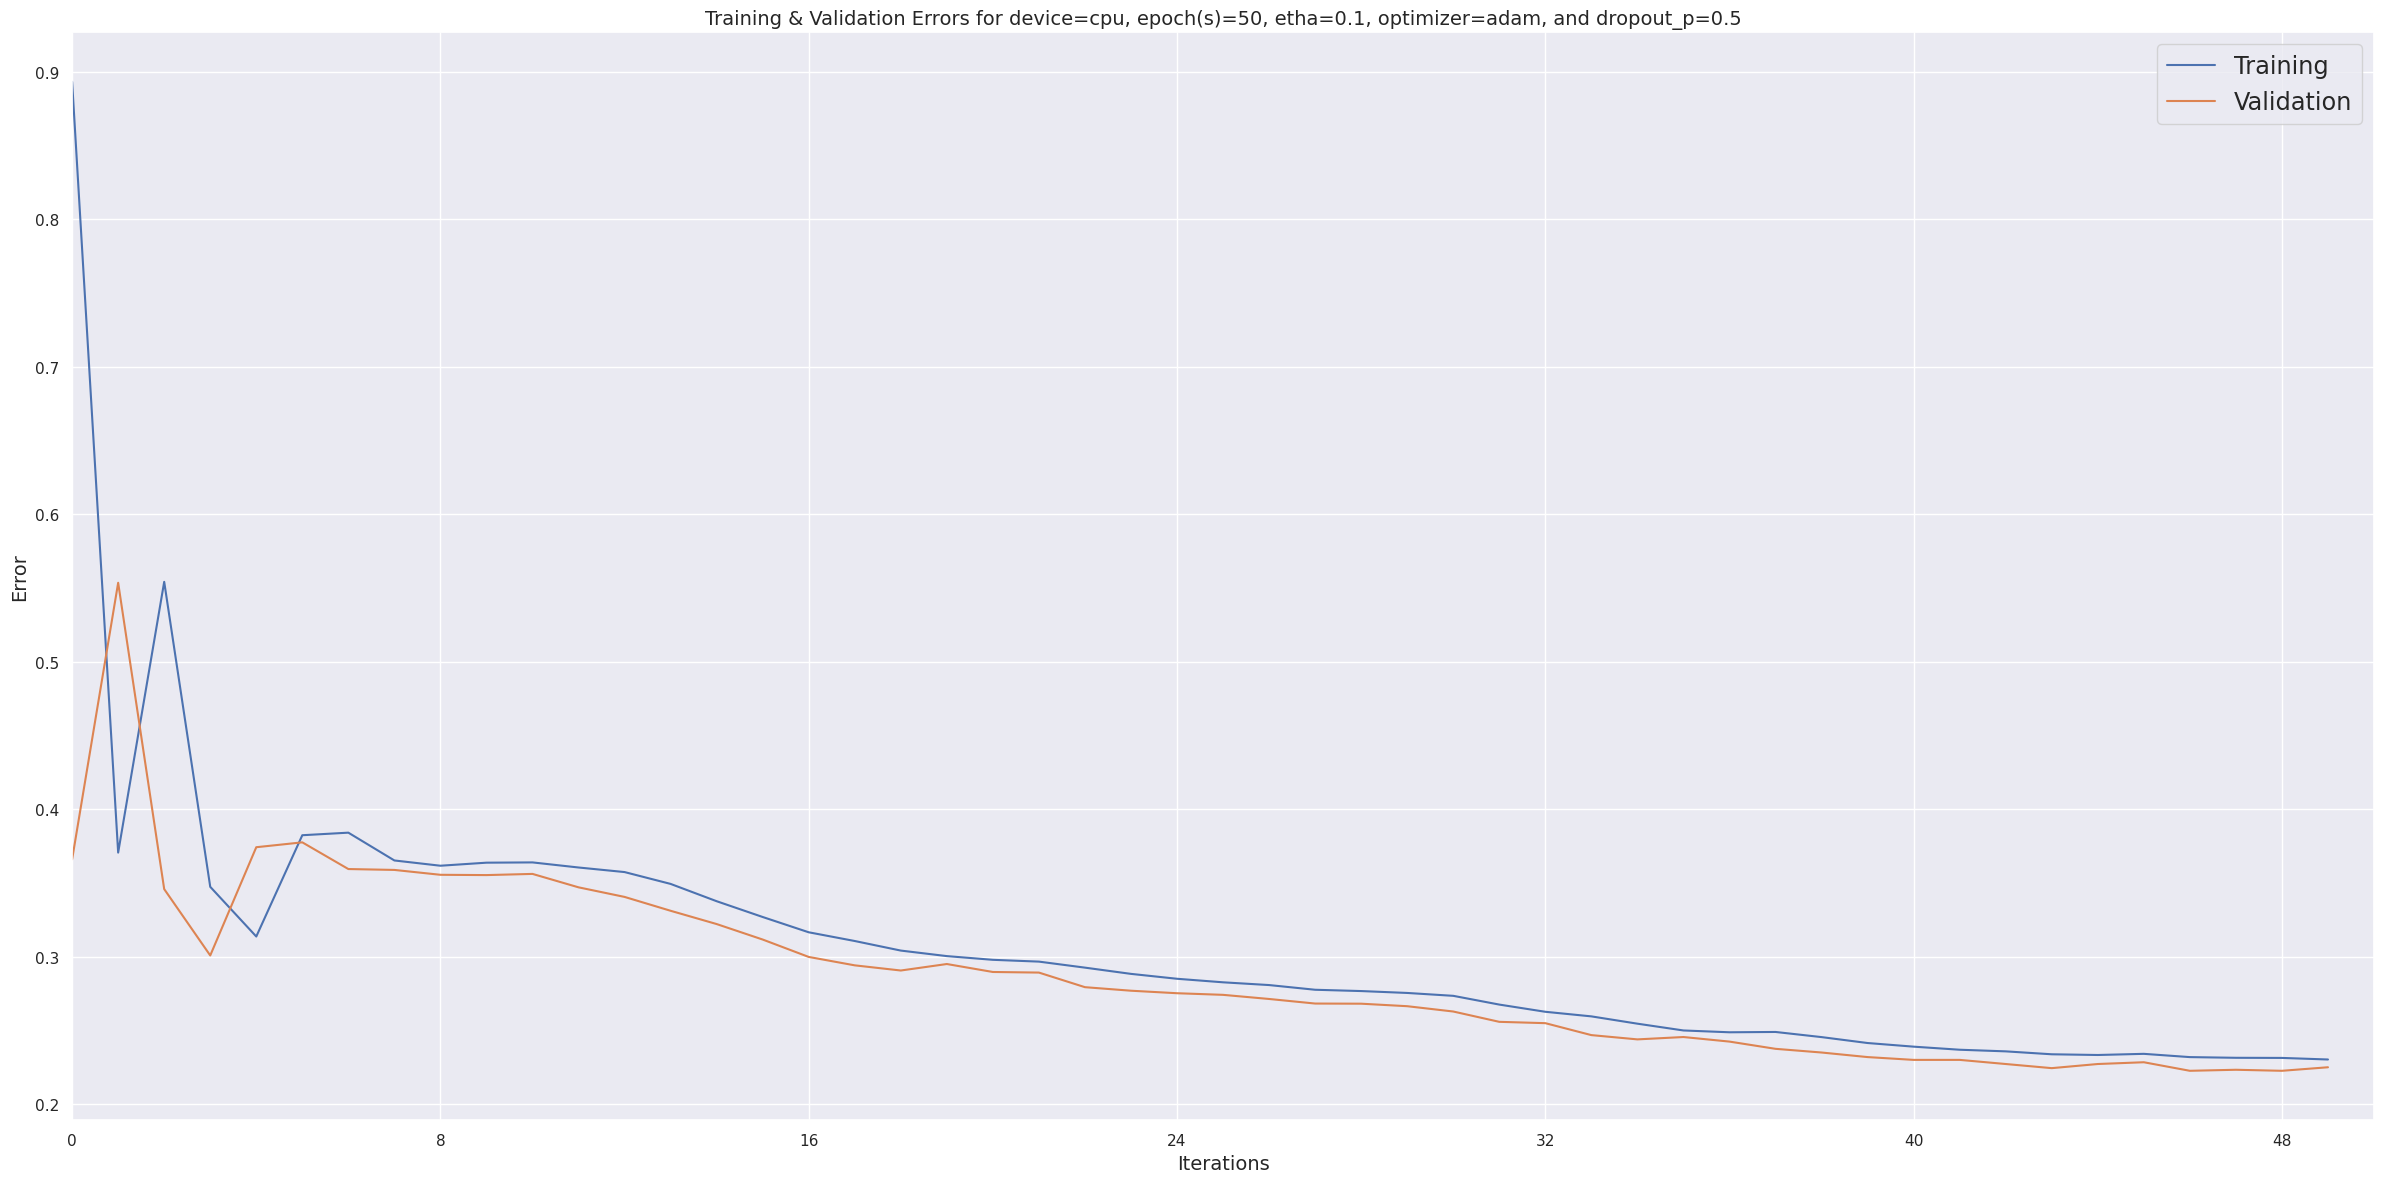

In [12]:
# P2.2.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Error"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training3_idps]
    , y1=[tld.training_error for tld in training3_idps]
    , y2=[tld.validation_error for tld in training3_idps]
    , title="Training & Validation Errors for {training}".format(training=training3)
)

In [13]:
# P2.2.
training4 = NeuralNetTraining(
    etha=0.01
    , dropout_p=0.5
    , optimizer_alg="adam"
    , loader_val=loader_val
    , loader_train=loader_train
    , device_name=Utils.get_device_name()
)

training4_idps = training4.train_and_validate()

100%|██████████| 50/50 [04:11<00:00,  5.03s/it]


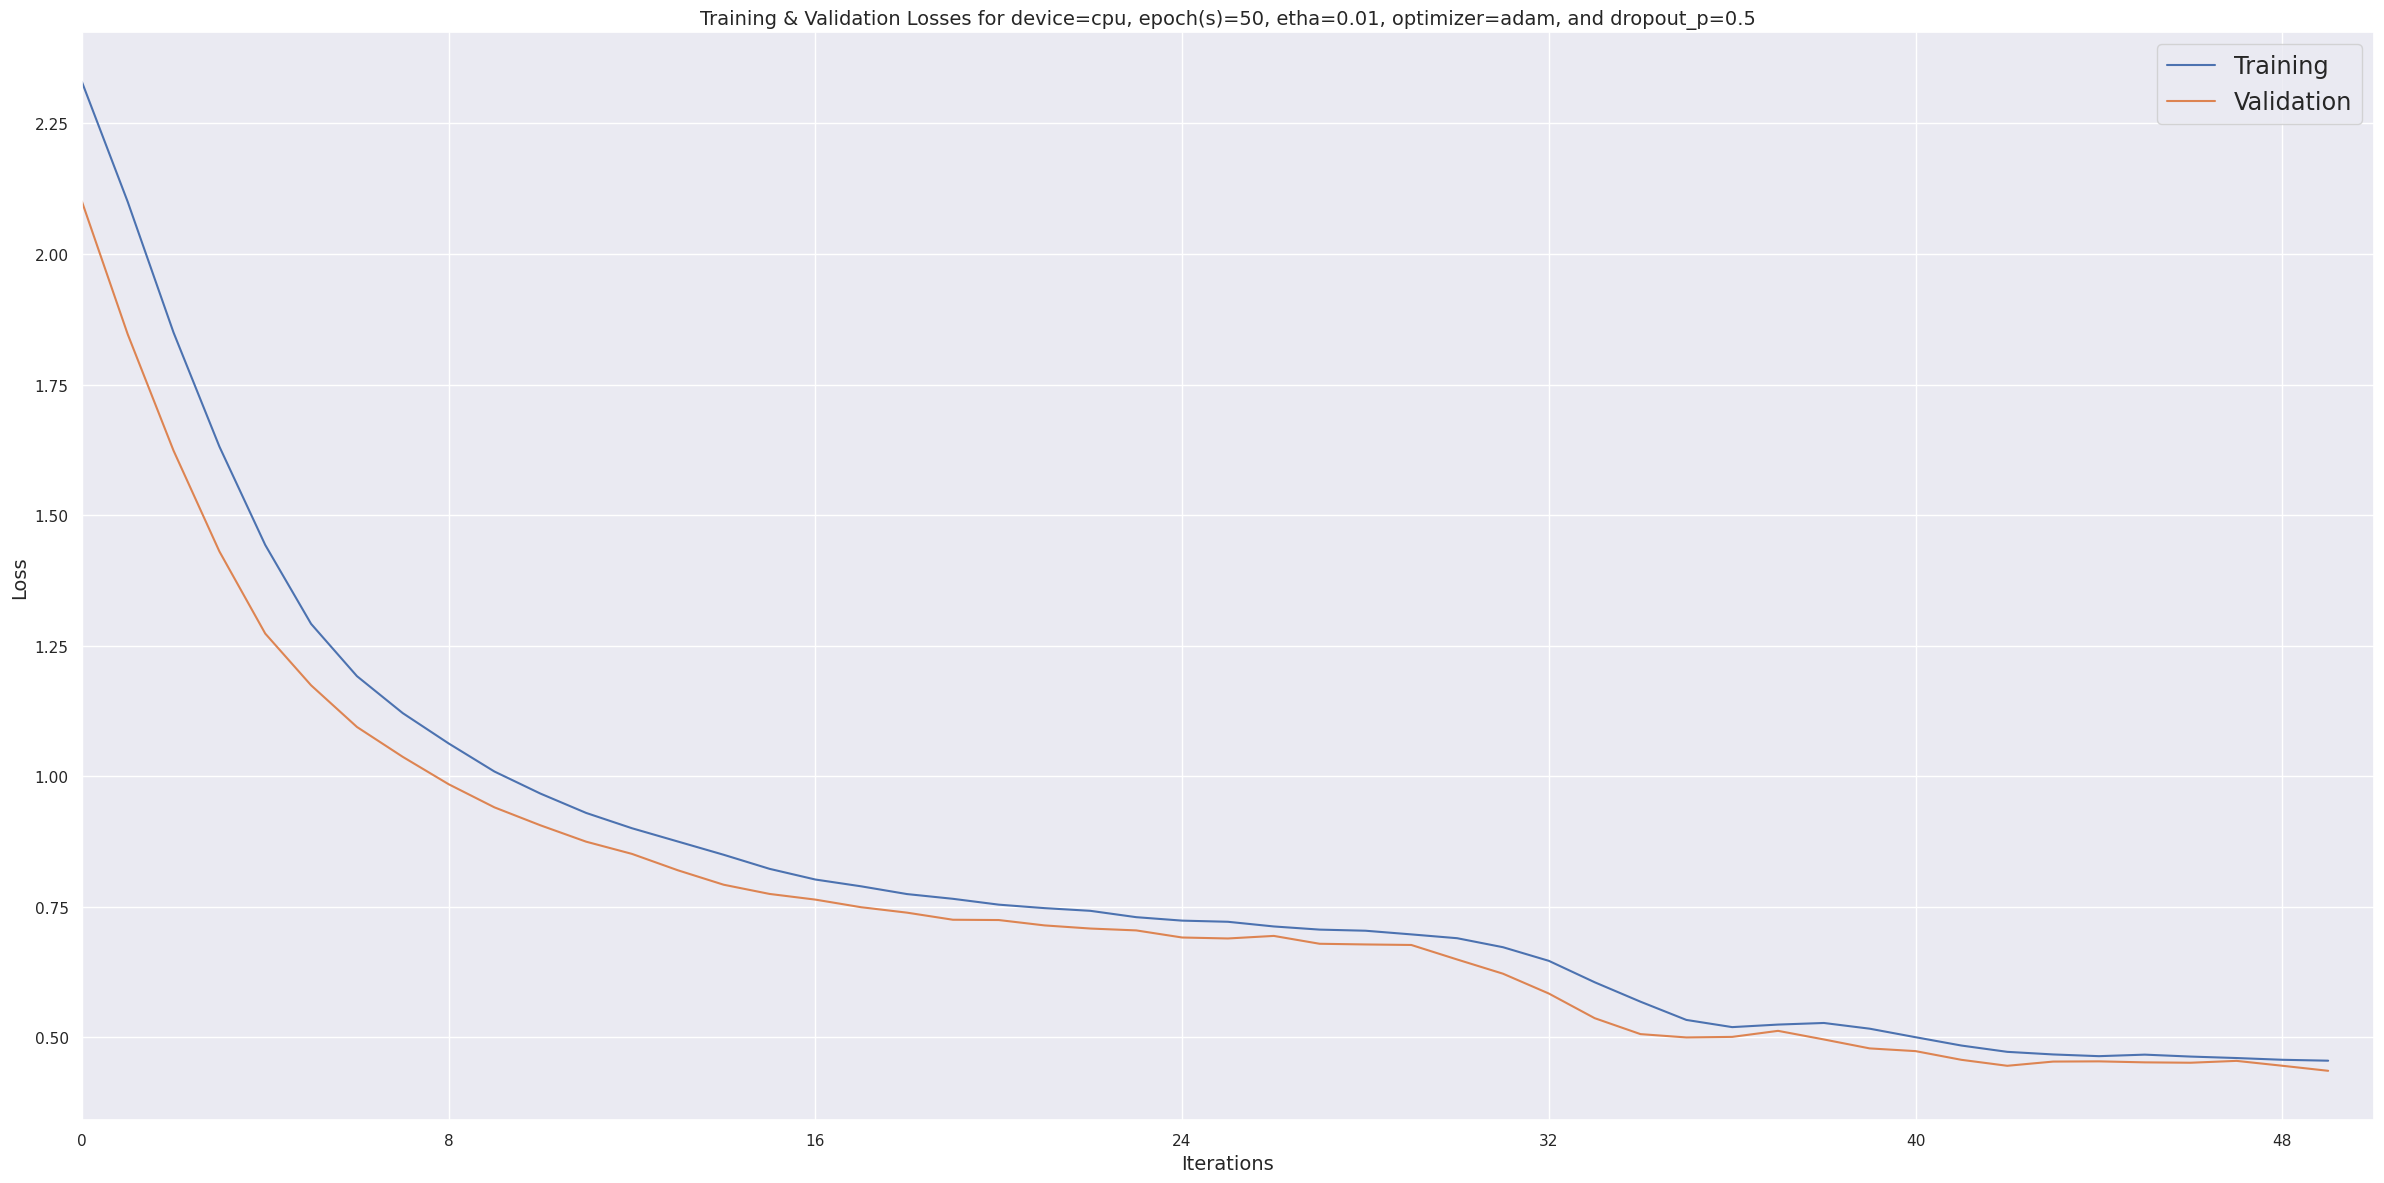

In [14]:
# P2.2.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training4_idps]
    , y1=[tld.training_loss for tld in training4_idps]
    , y2=[tld.validation_loss for tld in training4_idps]
    , title="Training & Validation Losses for {training}".format(training=training4)
)

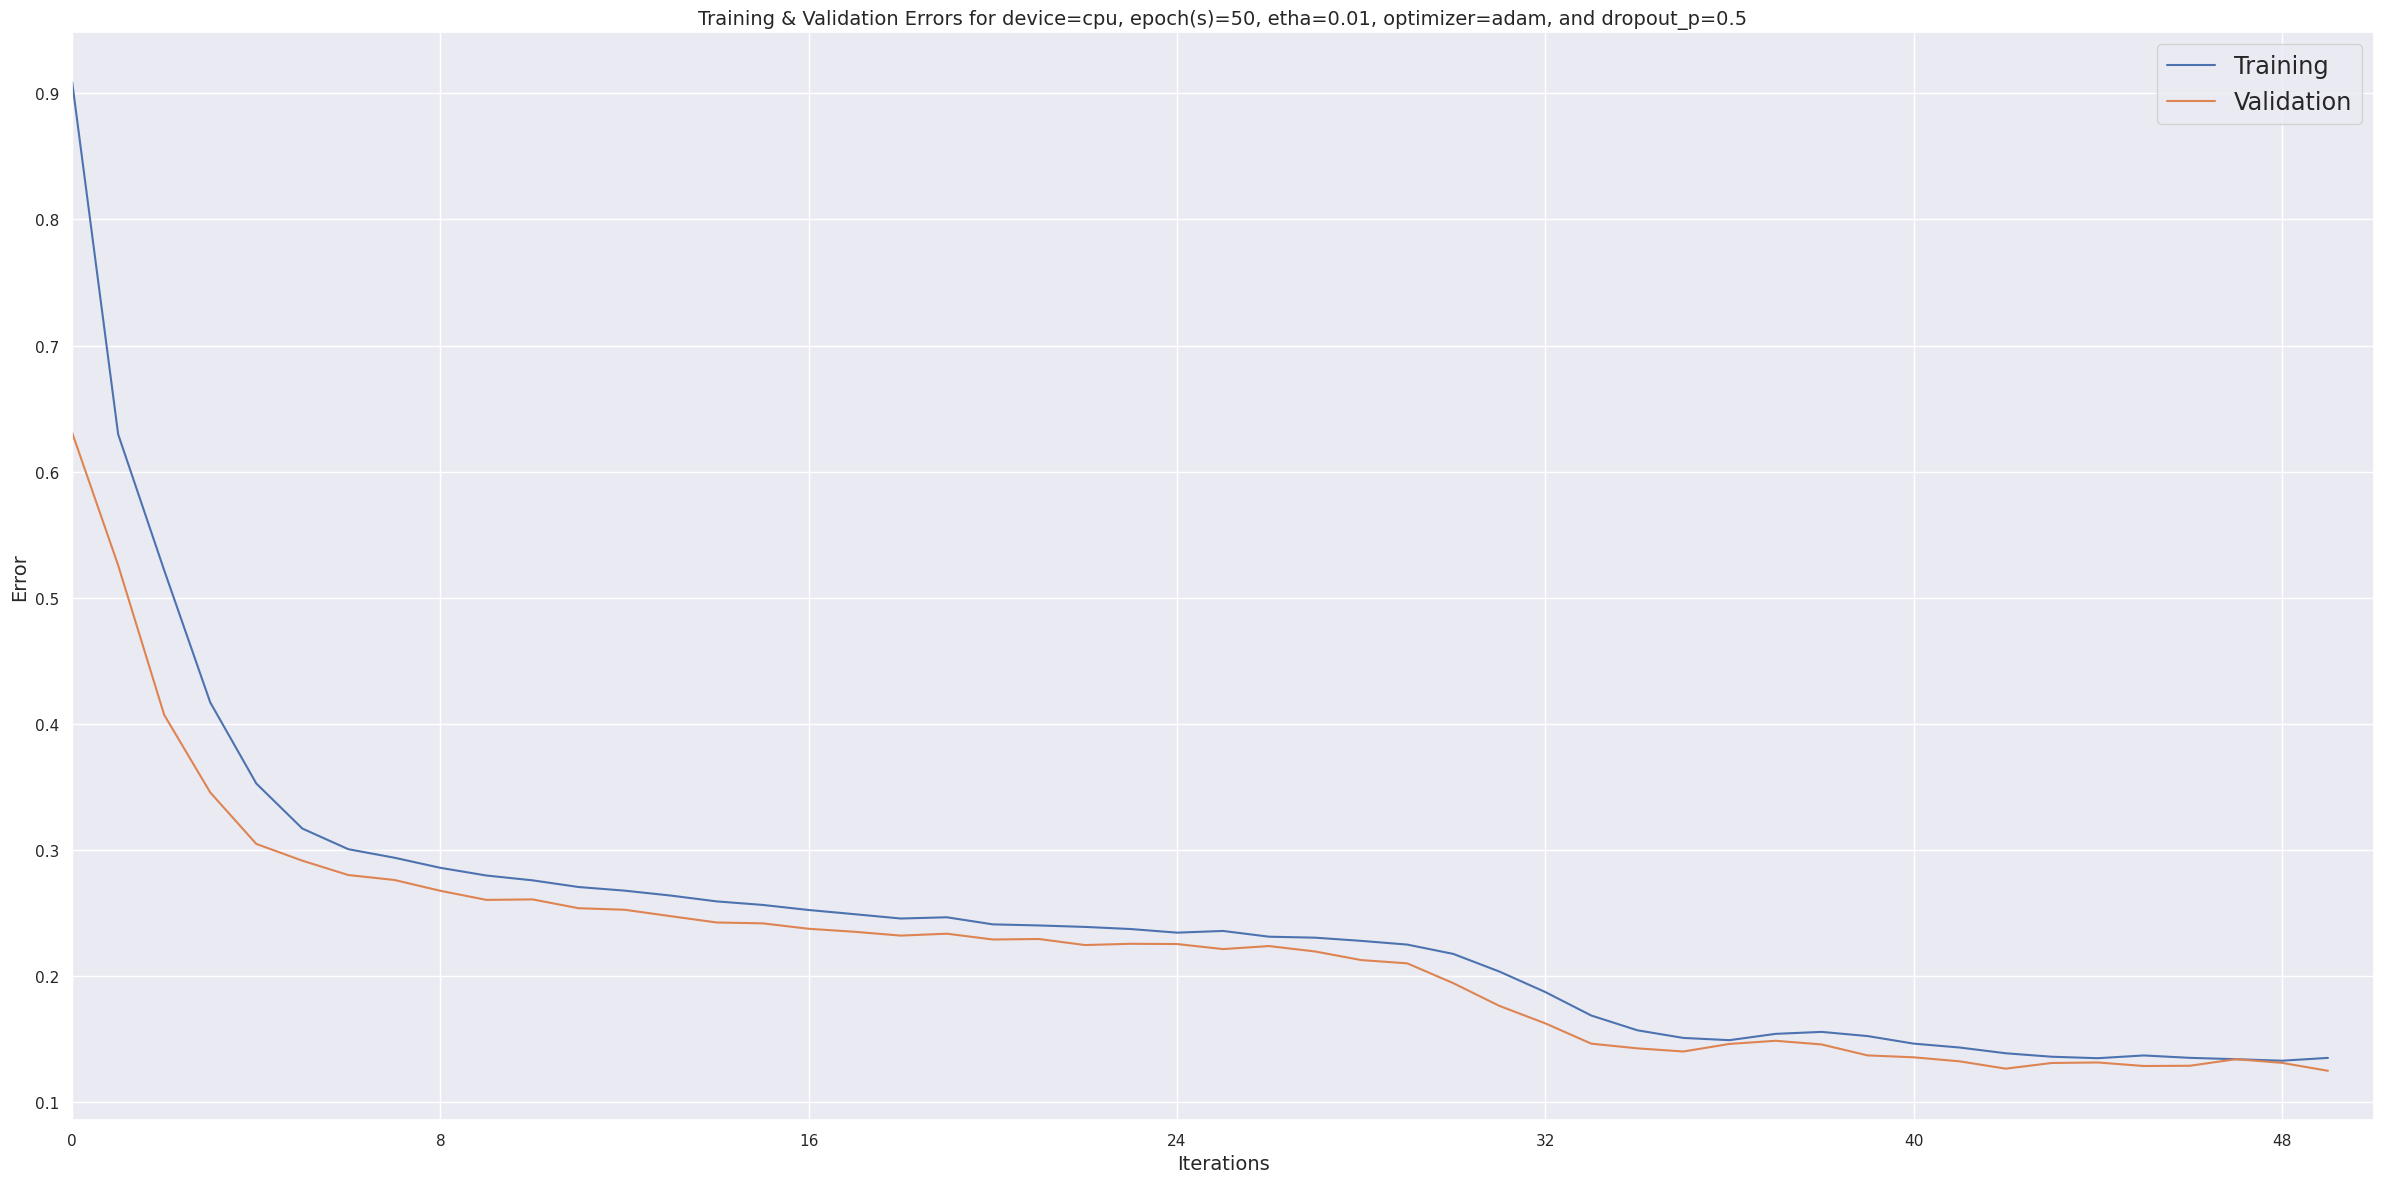

In [15]:
# P2.2.
Utils.two_line_plot(
    y1_legend="Training"
    , y_axis_label="Error"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in training4_idps]
    , y1=[tld.training_error for tld in training4_idps]
    , y2=[tld.validation_error for tld in training4_idps]
    , title="Training & Validation Errors for {training}".format(training=training4)
)